In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
# 1. Cargar el dataset 
X = np.load('X_MLII_flat.npy') 
print(f"Dataset cargado con forma: {X.shape}")

Dataset cargado con forma: (2272, 216)


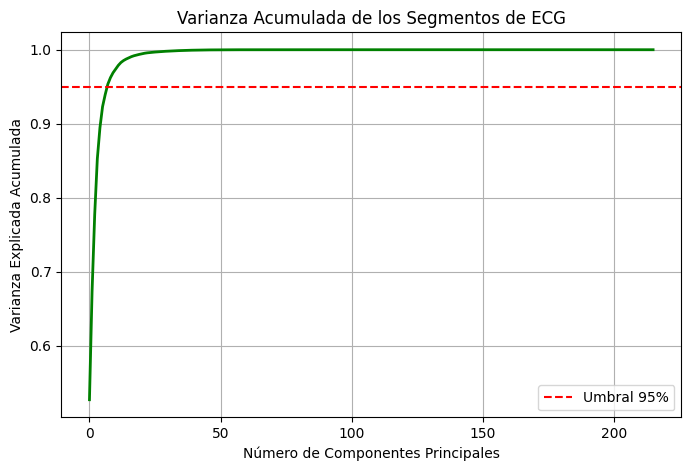

Para el 95% de varianza, se necesitan 8 componentes.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Entrenamos el PCA con todos los componentes
pca_full = PCA().fit(X) 
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Graficamos
plt.figure(figsize=(8, 5))
plt.plot(varianza_acumulada, linewidth=2, color='green')
plt.axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
plt.title('Varianza Acumulada de los Segmentos de ECG')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# Ver el número exacto
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Para el 95% de varianza, se necesitan {n_95} componentes.")

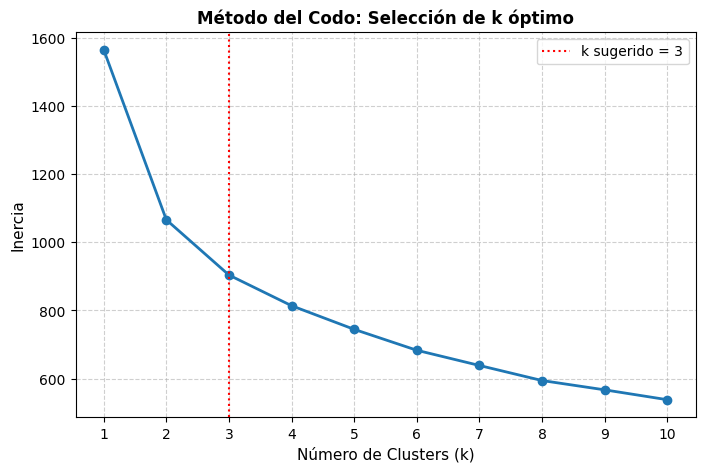

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Debemos aplicar el modelo a los datos originales para obtener la matriz numérica
X_pca = pca_full.transform(X)

# 1. Cálculo de inercia
ks = range(1, 11)
inercia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca).inertia_ for k in ks]

# 2. Configuración estética mínima
plt.figure(figsize=(8, 5))
plt.plot(ks, inercia, 'o-', color='#1f77b4', linewidth=2) # Línea sólida con puntos

# 3. Anotaciones críticas para el informe
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('Inercia', fontsize=11)
plt.title('Método del Codo: Selección de k óptimo', fontsize=12, fontweight='bold')
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.6)

# Resaltar el punto clave 
plt.axvline(x=3, color='red', linestyle=':', label='k sugerido = 3')
plt.legend()

plt.show()

In [10]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

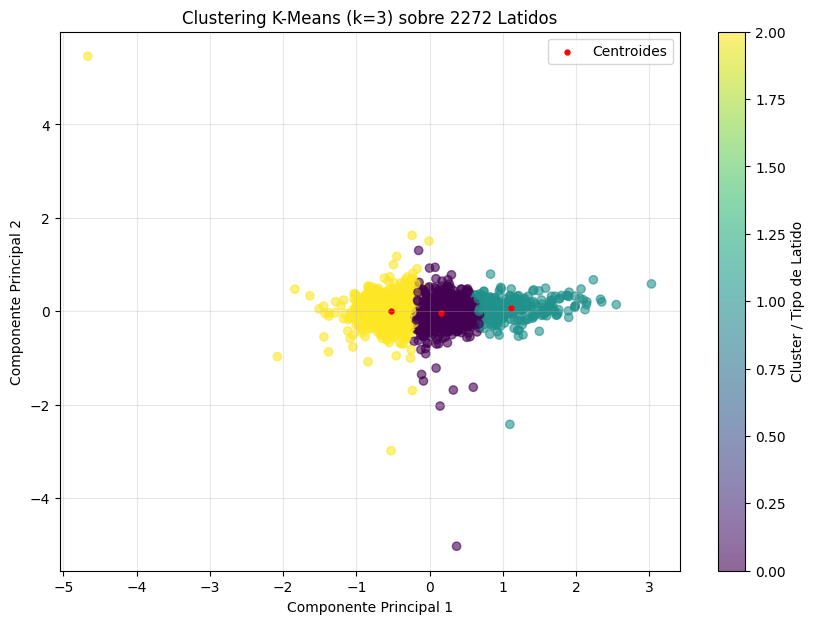

In [11]:
# Visualización en 2D (usando las 2 primeras componentes del PCA)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)

# Dibujar los centroides
centros = kmeans.cluster_centers_
plt.scatter(centros[:, 0], centros[:, 1], marker='.', s=50, color='red', label='Centroides')

plt.title(f'Clustering K-Means (k=3) sobre {X.shape[0]} Latidos', fontsize=12)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster / Tipo de Latido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

METRICAS PARA EL MODELO DE K-MEANS

In [12]:
from sklearn.metrics import silhouette_score

# Calcula la media del coeficiente de silueta para todos los latidos
silueta_media = silhouette_score(X_pca, labels)

print(f"Coeficiente de Silueta: {silueta_media:.4f}")

Coeficiente de Silueta: 0.2274


In [13]:
from sklearn.metrics import calinski_harabasz_score

# Esta métrica es más rápida de calcular
indice_ch = calinski_harabasz_score(X_pca, labels)

print(f"Índice Calinski-Harabasz: {indice_ch:.2f}")

Índice Calinski-Harabasz: 829.34


In [14]:
from sklearn.metrics import davies_bouldin_score

# Calcula la razón de dispersión entre clusters
indice_db = davies_bouldin_score(X_pca, labels)

print(f"Índice Davies-Bouldin: {indice_db:.4f}")

Índice Davies-Bouldin: 1.4057


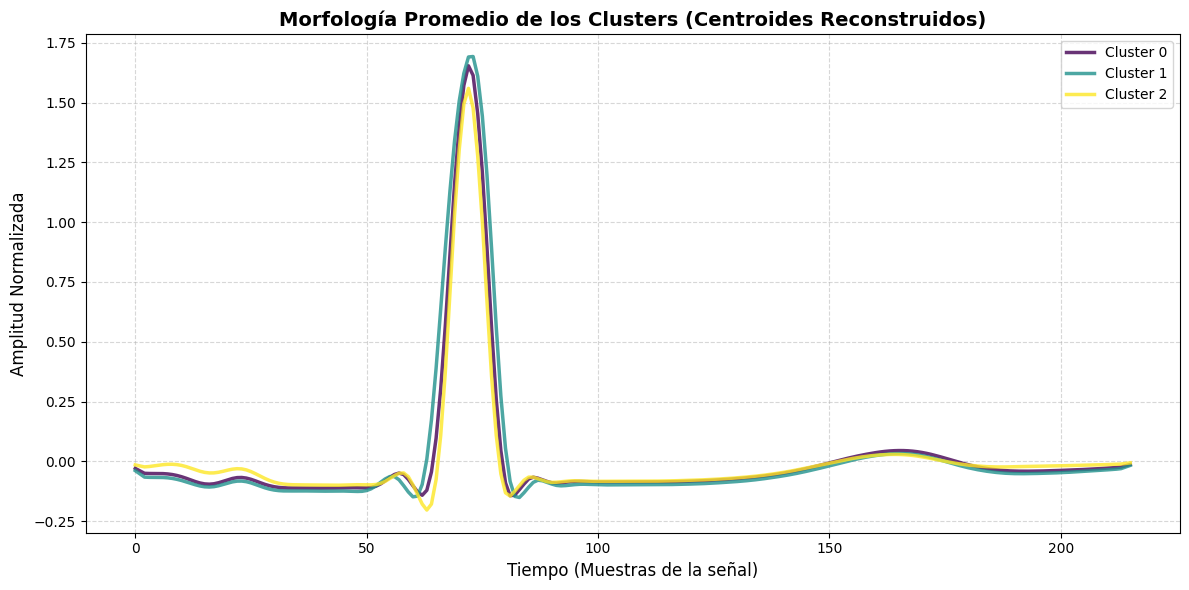

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Reconstrucción: Usamos 'pca_full' para volver de 8 a 216 puntos
# Esto funciona porque pca_full contiene la matriz de componentes (la "receta")
centroides_originales = pca_full.inverse_transform(kmeans.cluster_centers_)

# 2. Configuración de la gráfica
plt.figure(figsize=(12, 6))
# Colores sugeridos para diferenciar bien los tipos de latidos
colores = ['#440154', '#21918c', '#fde725'] 
nombres_clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(len(centroides_originales)):
    plt.plot(centroides_originales[i], label=nombres_clusters[i], 
             color=colores[i], linewidth=2.5, alpha=0.8)

# 3. Estética para tu informe de tesis
plt.title('Morfología Promedio de los Clusters (Centroides Reconstruidos)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Muestras de la señal)', fontsize=12)
plt.ylabel('Amplitud Normalizada', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

ALGORITMO DBSCAN

In [16]:
# CARGAMOS EL DATASET 
import numpy as np

X = np.load("X_MLII_flat.npy")
print("Shape del dataset:", X.shape)

Shape del dataset: (2272, 216)


In [17]:
# ESCALADO DEL DBSCAN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

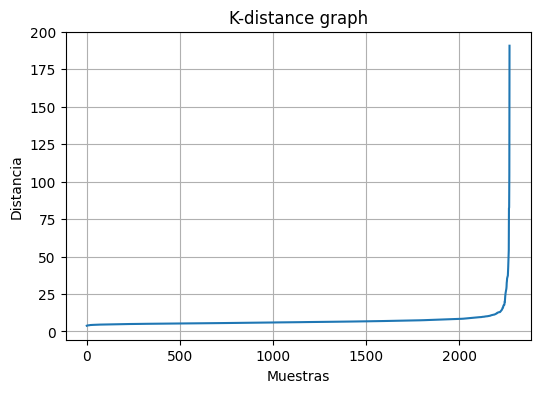

In [18]:
# BUSCAMOS EL EPS PARA EL ALGORTIMO
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-distance graph")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.grid()
plt.show()

In [19]:
#IMPLEMENTACION DEL MODELO
from sklearn.cluster import DBSCAN

# 1. Definimos el modelo con el EPS que encontramos en la gráfica
eps_elegido = 7.5
dbscan = DBSCAN(eps=eps_elegido, min_samples=5)

# 2. Ajustamos a los datos
clusters = dbscan.fit_predict(X_scaled)

# 3. Revisamos los resultados
labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'Número estimado de clústeres: {n_clusters_}')
print(f'Número estimado de puntos de ruido (outliers): {n_noise_}')

Número estimado de clústeres: 3
Número estimado de puntos de ruido (outliers): 287


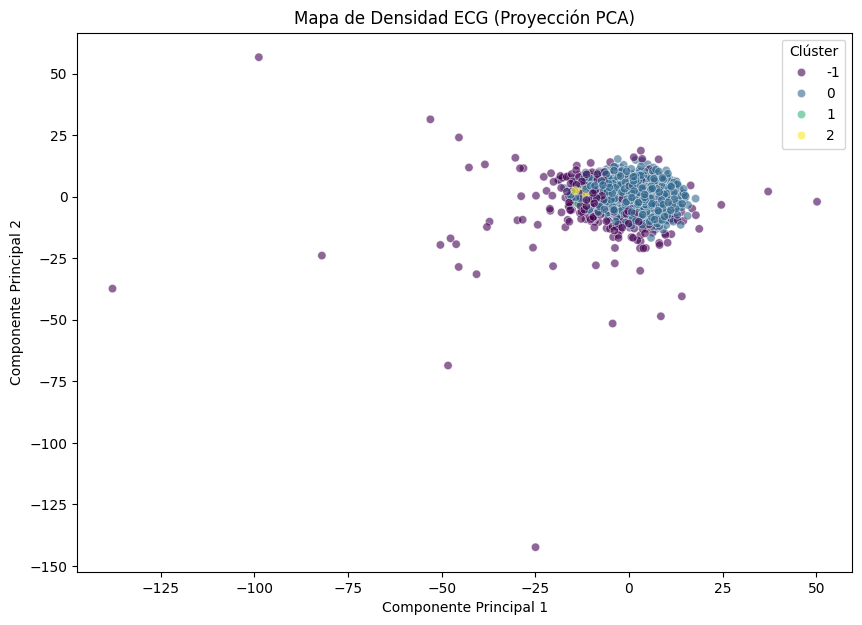

In [20]:
from sklearn.decomposition import PCA
import seaborn as sns

# Reducimos a 2 dimensiones para poder graficar en un plano X,Y
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, 
                palette='viridis', markers='.', alpha=0.6)
plt.title("Mapa de Densidad ECG (Proyección PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Clúster")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

# Excluimos el ruido (-1) para una métrica más limpia de los grupos formados
mask = labels != -1
score = silhouette_score(X_scaled[mask], labels[mask])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.203


In [22]:
from sklearn.metrics import calinski_harabasz_score

# Excluir puntos de ruido (-1)
mask = labels != -1
ch_score = calinski_harabasz_score(X_scaled[mask], labels[mask])
print(f"Calinski-Harabasz Score: {ch_score:.3f}")

Calinski-Harabasz Score: 13.795


In [23]:
from sklearn.metrics import davies_bouldin_score

# Excluir puntos de ruido (-1)
mask = labels != -1
db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 1.260


ALGORITMO OPTICS

In [24]:
from sklearn.cluster import OPTICS
from sklearn.preprocessing import StandardScaler

# Es importante que que los datos estén escalados para que la distancia sea justa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# Inicializar el modelo
# metric='euclidean' es el estándar para señales morfométricas
optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)

# Entrenar con tus datos escalados
optics_model.fit(X_scaled)

,"min_samples min_samples: int > 1 or float between 0 and 1, default=5The number of samples in a neighborhood for a point to be considered asa core point. Also, up and down steep regions can't have more than``min_samples`` consecutive non-steep points. Expressed as an absolutenumber or a fraction of the number of samples (rounded to be at least2).",10
,"max_eps max_eps: float, default=np.infThe maximum distance between two samples for one to be considered asin the neighborhood of the other. Default value of ``np.inf`` willidentify clusters across all scales; reducing ``max_eps`` will resultin shorter run times.",inf
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Any metric from scikit-learnor :mod:`scipy.spatial.distance` can be used.If `metric` is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays as input and return one value indicating thedistance between them. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string. If metric is""precomputed"", `X` is assumed to be a distance matrix and must besquare.Valid values for metric are:- from scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan']- from scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']Sparse matrices are only supported by scikit-learn metrics.See :mod:`scipy.spatial.distance` for details on these metrics... note:: `'kulsinski'` is deprecated from SciPy 1.9 and will be removed in SciPy 1.11.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:class:`~sklearn.metrics.pairwise_distances`. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"cluster_method cluster_method: {'xi', 'dbscan'}, default='xi'The extraction method used to extract clusters using the calculatedreachability and ordering.",'xi'
,"eps eps: float, default=NoneThe maximum distance between two samples for one to be considered asin the neighborhood of the other. By default it assumes the same valueas ``max_eps``.Used only when ``cluster_method='dbscan'``.",None
,"xi xi: float between 0 and 1, default=0.05Determines the minimum steepness on the reachability plot thatconstitutes a cluster boundary. For example, an upwards point in thereachability plot is defined by the ratio from one point to itssuccessor being at most 1-xi.Used only when ``cluster_method='xi'``.",0.05
,"predecessor_correction predecessor_correction: bool, default=TrueCorrect clusters according to the predecessors calculated by OPTICS[2]_. This parameter has minimal effect on most datasets.Used only when ``cluster_method='xi'``.",True
,"min_cluster_size min_cluster_size: int > 1 or float between 0 and 1, default=NoneMinimum number of samples in an OPTICS cluster, expressed as anabsolute number or a fraction of the number of samples (rounded to beat least 2). If ``None``, the value of ``min_samples`` is used instead.Used only when ``cluster_method='xi'``.",0.05
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`~sklearn.neighbors.BallTree`.- 'kd_tree' will use :class:`~sklearn.neighbors.KDTree`.- 'brute' will use a brute-force search.- 'auto' (default) will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'


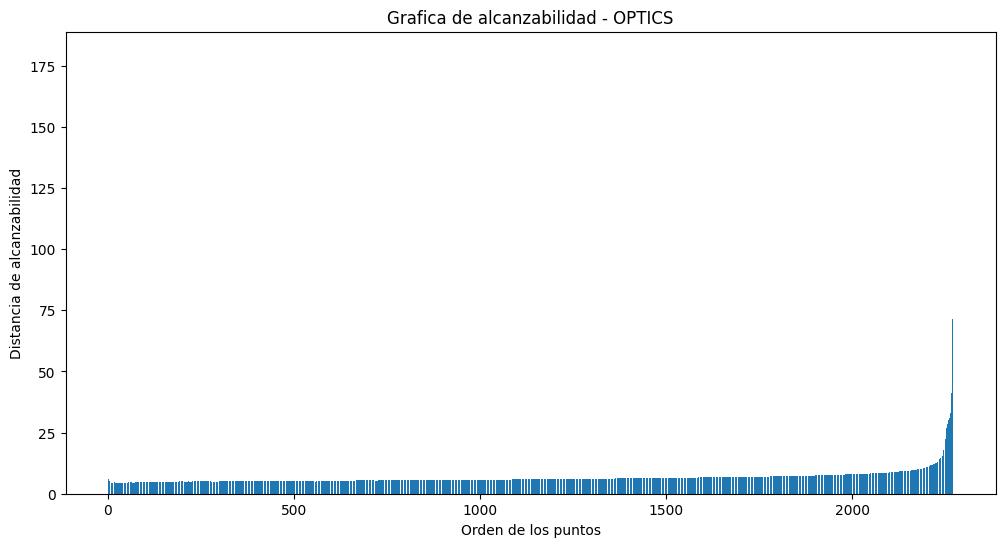

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Crear eje x (orden de los puntos)
space = np.arange(len(X_scaled))

# Obtener reachability y labels ordenados
reachability = optics_model.reachability_[optics_model.ordering_]
labels = optics_model.labels_[optics_model.ordering_]

# Gráfica 
plt.figure(figsize=(12, 6))
plt.bar(space, reachability)
plt.xlabel("Orden de los puntos")
plt.ylabel("Distancia de alcanzabilidad")
plt.title("Grafica de alcanzabilidad - OPTICS")
plt.show()

In [34]:
import matplotlib.pyplot as plt

# Separar índices de latidos normales (Cluster 0) y anómalos (Ruido -1)
indices_normales = np.where(optics_model.labels_ == 0)[0]
indices_anomalos = np.where(optics_model.labels_ == -1)[0]

print(f"Latidos detectados como Normales (Cluster 0): {len(indices_normales)}")
print(f"Latidos detectados como Anómalos (Ruido -1): {len(indices_anomalos)}")

# Seleccionamos una muestra para graficar (por ejemplo, el primero de cada grupo)
muestra_normal = X[indices_normales[0]]
muestra_anomala = X[indices_anomalos[0]] if len(indices_anomalos) > 0 else None

Latidos detectados como Normales (Cluster 0): 2252
Latidos detectados como Anómalos (Ruido -1): 20


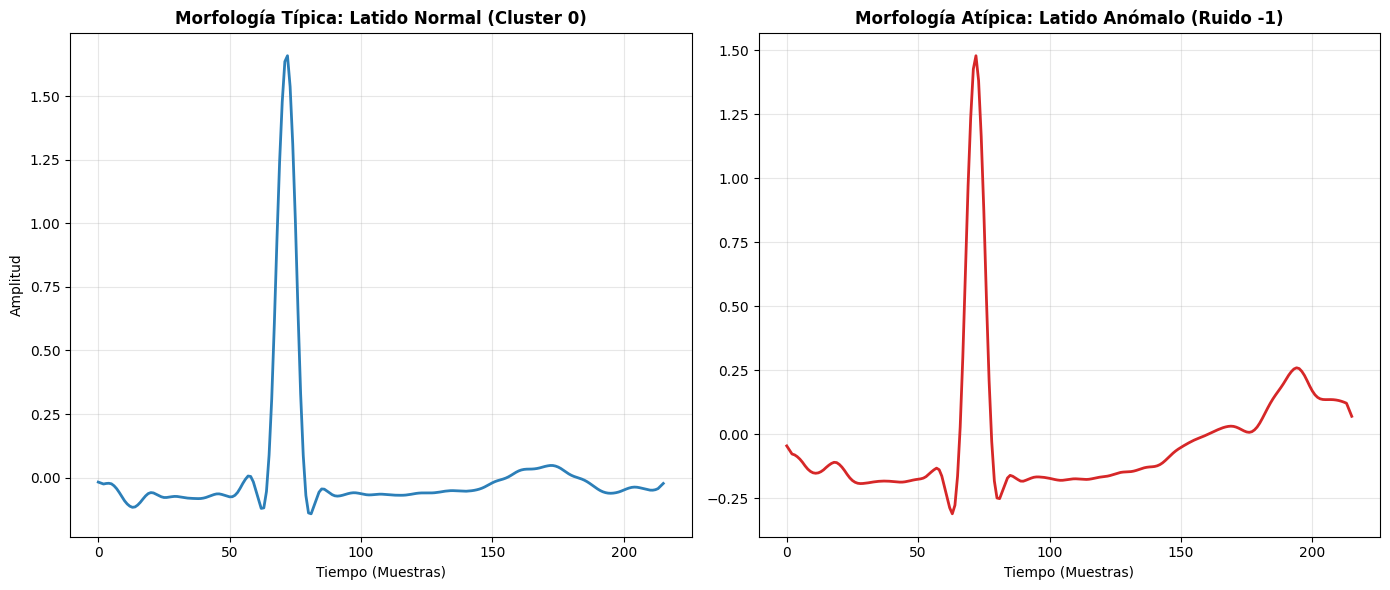

In [35]:
plt.figure(figsize=(14, 6))

# Graficar Latido Normal
plt.subplot(1, 2, 1)
plt.plot(muestra_normal, color='#2c7fb8', linewidth=2)
plt.title('Morfología Típica: Latido Normal (Cluster 0)', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

# Graficar Latido Anómalo
if muestra_anomala is not None:
    plt.subplot(1, 2, 2)
    plt.plot(muestra_anomala, color='#d62728', linewidth=2)
    plt.title('Morfología Atípica: Latido Anómalo (Ruido -1)', fontsize=12, fontweight='bold')
    plt.xlabel('Tiempo (Muestras)')
    plt.grid(True, alpha=0.3)
else:
    print("No se encontraron latidos anómalos con los parámetros actuales.")

plt.tight_layout()
plt.show()

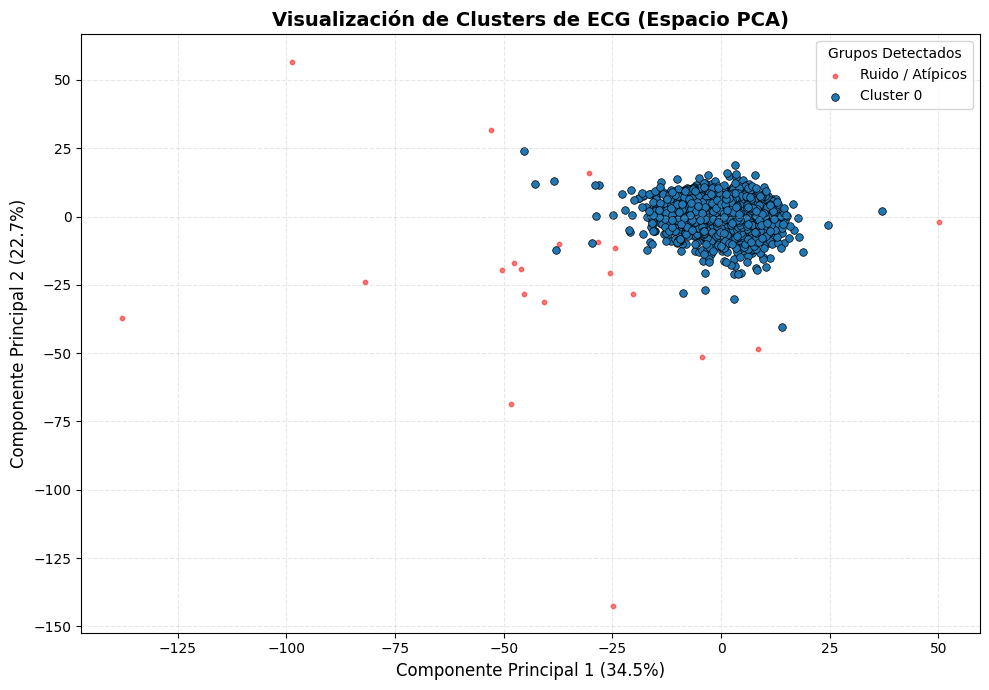

In [ ]:
# 1. Reducimos a 2 dimensiones para poder graficar en un plano X-Y
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled) # O usa X_scaled si prefieres

# 2. Extraer las etiquetas de OPTICS
labels = optics_model.labels_

# 3. Configurar la gráfica
plt.figure(figsize=(10, 7))

# Graficar el Ruido (Label -1) en color gris 
plt.scatter(X_2d[labels == -1, 0], X_2d[labels == -1, 1], 
            c='red', s=10, label='Ruido / Atípicos', alpha=0.5)

# Graficar los Clusters detectados (0, 1, 2...)
# Usamos un bucle para que cada cluster tenga su propio color
unique_labels = set(labels)
if -1 in unique_labels: unique_labels.remove(-1)

for k in unique_labels:
    plt.scatter(X_2d[labels == k, 0], X_2d[labels == k, 1], 
                s=30, label=f'Cluster {k}', edgecolors='k', linewidths=0.5)

# 4. Estética de Tesis
plt.title('Visualización de Clusters de ECG (Espacio PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.legend(title="Grupos Detectados")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()